In [1]:
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
import scipy
from sandbox.jordan5 import setup_device
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sandbox.jordan7 import *

In [2]:
def test_jordan_net(model, d, matrices_per_class=1000, mode="random", eps=None, eps_range=None):
    model.eval()

    matrices_test, labels_test, features_test, masks_test, dists_test = generate_training_dataset(
        matrices_per_class=matrices_per_class,
        d=d,
        mode=mode,
        eps=eps,
        eps_range=eps_range,
        device="cpu",
    )

    loader = DataLoader(TensorDataset(features_test, labels_test, masks_test, dists_test), batch_size=64, shuffle=False)

    predicted_classes = []
    true_classes = labels_test.cpu().tolist()
    kl_avg = 0.0

    for batch_features, batch_labels, batch_masks, batch_dists in loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)
        batch_masks = batch_masks.to(device)
        batch_dists = batch_dists.to(device)

        logits = model(batch_features, masks=batch_masks)
        # logits = model(batch_features, masks=None)
        loss = kl_loss(logits, batch_dists)

        preds = torch.argmax(logits, dim=-1)
        predicted_classes += preds.cpu().tolist()
        kl_avg += loss.item() * batch_features.size(0)

    kl_avg /= len(loader.dataset)
    # print(f"Test KL Loss: {kl_avg:.6f}")

    cm = confusion_matrix(true_classes, predicted_classes)

    return cm, kl_avg



# Training

In [ ]:
torch.manual_seed(0)
np.random.seed(0)

d = 5

model = JordanNet(d=d, num_classes=d, encode_dim=32)

matrices, labels, features, masks, dists = generate_training_dataset(
    matrices_per_class=20_000,
    d=d,
    mode="random",
    device=device,
)

print(dists.mean(dim=0))
print(dists.std(dim=0))
print(dists.max(), dists.min())

model = train_jordan_net(
    model,
    features,
    masks,
    dists,
    num_epochs=20,
    device=device,
)

Generating class with max_block_size=1...Done.
Generating class with max_block_size=2...Done.
Generating class with max_block_size=3...Done.
Generating class with max_block_size=4...Done.
Generating class with max_block_size=5...Done.
Generating class with max_block_size=6...Done.
Generating class with max_block_size=7...Done.
Generating class with max_block_size=8...Done.
Generating class with max_block_size=9...Done.
Generating class with max_block_size=10...Done.
Generating class with max_block_size=11...Done.
Generating class with max_block_size=12...Done.
Generating class with max_block_size=13...Done.
Generating class with max_block_size=14...Done.
Generating class with max_block_size=15...Done.
tensor([0.0650, 0.0677, 0.0673, 0.0669, 0.0665, 0.0667, 0.0668, 0.0664, 0.0669,
        0.0667, 0.0667, 0.0669, 0.0669, 0.0680, 0.0648],
       device='privateuseone:0')
tensor([0.2303, 0.2270, 0.2256, 0.2252, 0.2247, 0.2251, 0.2254, 0.2248, 0.2260,
        0.2255, 0.2250, 0.2249, 0.2244,

C:\Users\micha\AppData\Local\Temp\ipykernel_13796\74368023.py:16: UserWarning: The operator 'aten::std.correction' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  print(dists.std(dim=0))


: 

# Tests

C:\Users\micha\AppData\Local\Temp\ipykernel_17512\3543438579.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan7_{d}

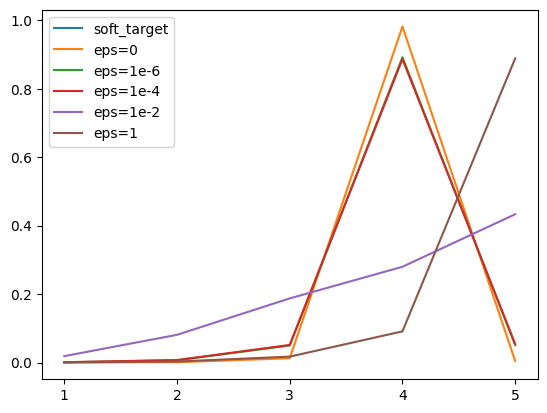

In [ ]:
d = 5

model.load_state_dict(torch.load(f"sandbox/model_jordan7_{d}.pth"))

max_block_size = 4

Xs = [generate_matrix(d, max_block_size, mode="random", eps=eps) for eps in [0, 1e-6, 1e-4, 1e-2, 1]]
X_batch = torch.tensor(Xs, dtype=torch.float32)
features = [per_power_features(X) for X in Xs]
X_features = torch.tensor([f[0] for f in features], dtype=torch.float32)
masks = torch.tensor([f[1] for f in features], dtype=torch.float32)

model.eval()
logits = model(X_features.to(device), masks=masks.to(device))
# logits = model(X_features.to(device), masks=None)
probs = torch.softmax(logits, dim=-1)
probs = probs.detach().cpu().numpy()

plt.plot(soft_target(torch.tensor([max_block_size]), eps=torch.tensor(1e-4), d=d).cpu().numpy()[0], label="soft_target")

for prob, label in zip(probs, ["eps=0", "eps=1e-6", "eps=1e-4", "eps=1e-2", "eps=1"]):
    plt.plot(prob, label=label)
plt.legend()
plt.xticks(ticks=range(5), labels=range(1,6))
plt.show()

Generating class with max_block_size=1...Done.
Generating class with max_block_size=2...Done.
Generating class with max_block_size=3...Done.
Generating class with max_block_size=4...Done.
Generating class with max_block_size=5...Done.
Generating class with max_block_size=1...Done.
Generating class with max_block_size=2...Done.
Generating class with max_block_size=3...Done.
Generating class with max_block_size=4...Done.
Generating class with max_block_size=5...Done.
Generating class with max_block_size=1...Done.
Generating class with max_block_size=2...Done.
Generating class with max_block_size=3...Done.
Generating class with max_block_size=4...Done.
Generating class with max_block_size=5...Done.
Generating class with max_block_size=1...Done.
Generating class with max_block_size=2...Done.
Generating class with max_block_size=3...Done.
Generating class with max_block_size=4...Done.
Generating class with max_block_size=5...Done.
Generating class with max_block_size=1...Done.
Generating cl

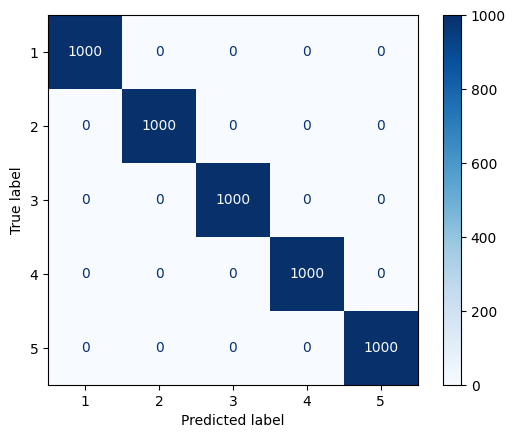

eps=1e-06:
	Accuracy 0.9994,
	KL loss 0.042667 


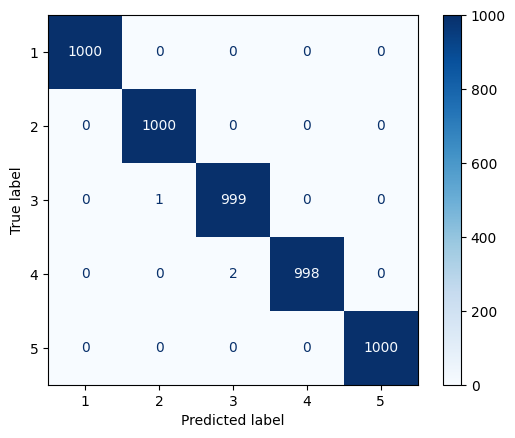

eps=0.0001:
	Accuracy 0.9958,
	KL loss 0.467485 


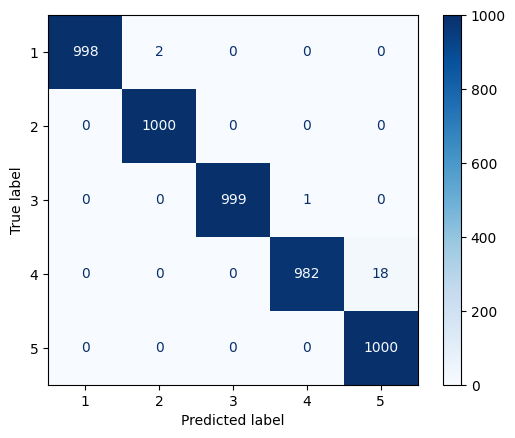

eps=0.01:
	Accuracy 0.6762,
	KL loss 0.303249 


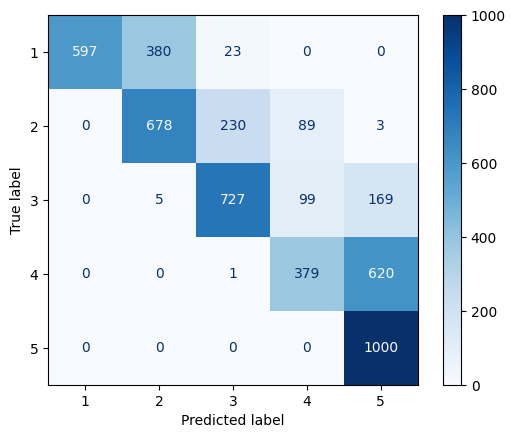

eps=0.1:
	Accuracy 0.2160,
	KL loss 1.394660 


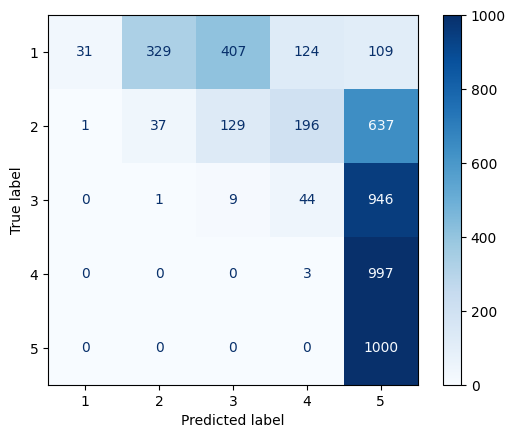

eps=1.0:
	Accuracy 0.2000,
	KL loss 2.451082 


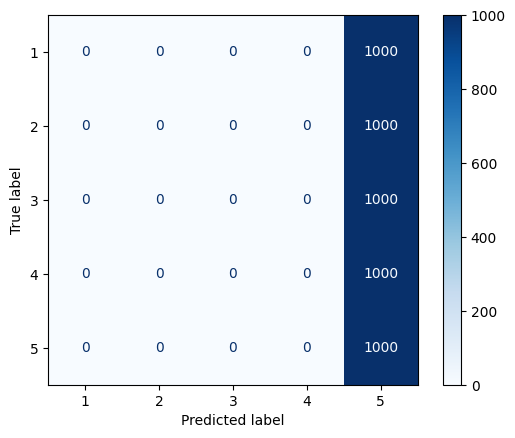

ortho:
	Accuracy 1.0000,
	KL loss 0.029630 


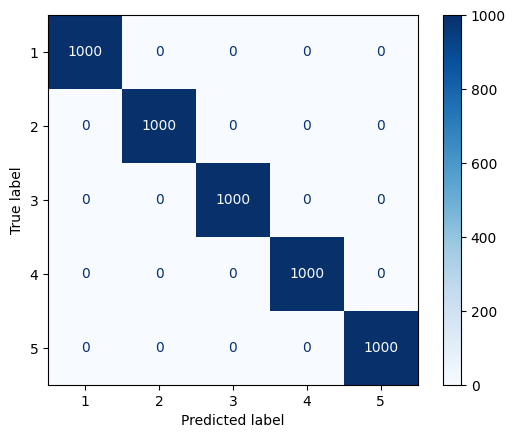

In [ ]:
cms = {}
kls = {}

model.to(device)

for eps in [0, 1e-6, 1e-4, 1e-2, 0.1, 1.]:
    cm, kl_div = test_jordan_net(model, d, mode="random", eps=eps, eps_range=None)
    cms[f"eps={eps}"] = cm
    kls[f"eps={eps}"] = kl_div

cm, kl_div = test_jordan_net(model, d, mode="ortho", eps=0., eps_range=None)
cms["ortho"] = cm
kls["ortho"] = kl_div

accuracies = {}
for eps, cm in cms.items():
    accuracy = np.trace(cm) / np.sum(cm)
    accuracies[eps] = accuracy

for k in accuracies.keys():
    print(f"{k}:\n\tAccuracy {accuracies[k]:.4f},\n\tKL loss {kls[k]:.6f} ")
    ConfusionMatrixDisplay(confusion_matrix=cms[k], display_labels=range(1, 6)).plot(cmap=plt.cm.Blues)
    plt.show()